#Eksplorasi dan Analisis Data COVID-19 Indonesia

#Eksplorasi Data

Import library request untuk melakukan HTTP request (mengakses API atau website)

In [22]:
import requests
#Mengirim HTTP GET request
resp = requests.get('https://storage.googleapis.com/dqlab-dataset/update.json', verify=False)

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'storage.googleapis.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


In [24]:
#Menampilkan objek response, jika 200 berarti request berhasil
print(resp)

<Response [200]>


In [25]:
#Menampilkan hearders dari response
print(resp.headers)

{'Content-Type': 'application/json', 'X-GUploader-UploadID': 'AMNfjG38rxYi78xMtWlER2KL4QNcA7jHquO5SRRsUc1-tRi-f122VOXa0vZ2kJENs0BjGb1y5Q9MKaIFygD5', 'Expires': 'Thu, 16 Apr 2026 03:15:09 GMT', 'Date': 'Thu, 16 Apr 2026 02:15:09 GMT', 'Cache-Control': 'public, max-age=3600', 'Last-Modified': 'Mon, 06 Jun 2022 11:12:39 GMT', 'ETag': '"f1a47ff36d3e95f63258d96fe5b2d439"', 'x-goog-generation': '1654513959565478', 'x-goog-metageneration': '1', 'x-goog-stored-content-encoding': 'identity', 'x-goog-stored-content-length': '311897', 'x-goog-hash': 'crc32c=GMMqEA==, md5=8aR/820+lfYyWNlv5bLUOQ==', 'x-goog-storage-class': 'STANDARD', 'Accept-Ranges': 'bytes', 'Content-Length': '311897', 'Server': 'UploadServer'}


In [26]:
#Mengubah response menjadi JSON
cov_id_raw = resp.json()

In [27]:
#Menampilkan panjang data
print('Length of cov_id_raw : %d.' %len(cov_id_raw))

#Menampilkan nama key utama
print('Komponen cov_id_raw  : %s.' %cov_id_raw.keys())

#Mengambil bagian update
cov_id_update = cov_id_raw['update']

Length of cov_id_raw : 2.
Komponen cov_id_raw  : dict_keys(['data', 'update']).


In [29]:
#Menampilkan data penambahan kasus
print('Tanggal pembaharuan data penambahan kasus   :', cov_id_update['penambahan']['tanggal'])
print('Jumlah penambahan kasus sembuh              :', cov_id_update['penambahan']['jumlah_sembuh'])
print('Jumlah penambahan kasus meninggal           :', cov_id_update['penambahan']['jumlah_meninggal'])

#Menampilkan data total kasus
print('Jumlah total kasus positif hingga saat ini  :', cov_id_update['total']['jumlah_positif'])
print('Jumlah total kasus meninggal hingga saat ini:', cov_id_update['total']['jumlah_meninggal'])

Tanggal pembaharuan data penambahan kasus   : 2022-05-14
Jumlah penambahan kasus sembuh              : 416
Jumlah penambahan kasus meninggal           : 5
Jumlah total kasus positif hingga saat ini  : 6050519
Jumlah total kasus meninggal hingga saat ini: 156453


Data Covid-19 provinsi Jawa Barat

In [30]:
resp_jabar = requests.get('https://storage.googleapis.com/dqlab-dataset/prov_detail_JAWA_BARAT.json', verify=False)
cov_jabar_raw = resp_jabar.json()

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'storage.googleapis.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


In [32]:
print('Nama-nama elemen utama:\n', cov_jabar_raw.keys())
print('\nJumlah total kasus COVID-19 di Jawa Barat                 : %d' %cov_jabar_raw['kasus_total'])
print('Persentase kematian akibat COVID-19 di Jawa Barat         : %f.2%%' % cov_jabar_raw['meninggal_persen'])
print('Persentase tingkat kesembuhan dari COVID-19 di Jawa Barat : %f.2%%' %cov_jabar_raw['sembuh_persen'])

Nama-nama elemen utama:
 dict_keys(['last_date', 'provinsi', 'kasus_total', 'kasus_tanpa_tgl', 'kasus_dengan_tgl', 'meninggal_persen', 'meninggal_tanpa_tgl', 'meninggal_dengan_tgl', 'sembuh_persen', 'sembuh_tanpa_tgl', 'sembuh_dengan_tgl', 'list_perkembangan', 'data'])

Jumlah total kasus COVID-19 di Jawa Barat                 : 1105134
Persentase kematian akibat COVID-19 di Jawa Barat         : 1.425619.2%
Persentase tingkat kesembuhan dari COVID-19 di Jawa Barat : 98.282380.2%


In [33]:
import numpy as np  #untuk komputasi numerik
import pandas as pd # untuk mengolah data berbentuk tabel (DataFrame)

In [34]:
#Membuat DataFrame
cov_jabar = pd.DataFrame(cov_jabar_raw['list_perkembangan'])
print('Info cov_jabar:\n', cov_jabar.info())
print('\nLima data teratas cov_jabar:\n', cov_jabar.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785 entries, 0 to 784
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   tanggal                       785 non-null    int64
 1   KASUS                         785 non-null    int64
 2   MENINGGAL                     785 non-null    int64
 3   SEMBUH                        785 non-null    int64
 4   DIRAWAT_OR_ISOLASI            785 non-null    int64
 5   AKUMULASI_KASUS               785 non-null    int64
 6   AKUMULASI_SEMBUH              785 non-null    int64
 7   AKUMULASI_MENINGGAL           785 non-null    int64
 8   AKUMULASI_DIRAWAT_OR_ISOLASI  785 non-null    int64
dtypes: int64(9)
memory usage: 55.3 KB
Info cov_jabar:
 None

Lima data teratas cov_jabar:
          tanggal  KASUS  MENINGGAL  SEMBUH  DIRAWAT_OR_ISOLASI  \
0  1583193600000      1          1       0                   0   
1  1583280000000      1          0       0   

#Data Cleaning

Membuat DataFrame menjadi lebih rapi

In [35]:
#Menghapus kolom tertentu
cov_jabar_tidy = (cov_jabar.drop(columns=[item for item in cov_jabar.columns
                                               if item.startswith('AKUMULASI') #data total kumulatif
                                                  or item.startswith('DIRAWAT')]) #data pasien dirawat
                           .rename(columns=str.lower) #Mengubah nama kolom menjadi huruf kecil
                           .rename(columns={'kasus': 'kasus_baru'}) #Mengganti nama kolom
                  )

Mengubah format tanggal

In [36]:
# pd.to_datetime() untuk mengubah angka timestamp menjadi format tanggal yang bisa dibaca
cov_jabar_tidy['tanggal'] = pd.to_datetime(cov_jabar_tidy['tanggal']*1e6, unit='ns')
print('Lima data teratas:\n',cov_jabar_tidy.head())

Lima data teratas:
      tanggal  kasus_baru  meninggal  sembuh
0 2020-03-03           1          1       0
1 2020-03-04           1          0       0
2 2020-03-05           1          0       0
3 2020-03-06           1          0       0
4 2020-03-07           0          0       0


#Visualisasi

<Figure size 640x480 with 0 Axes>

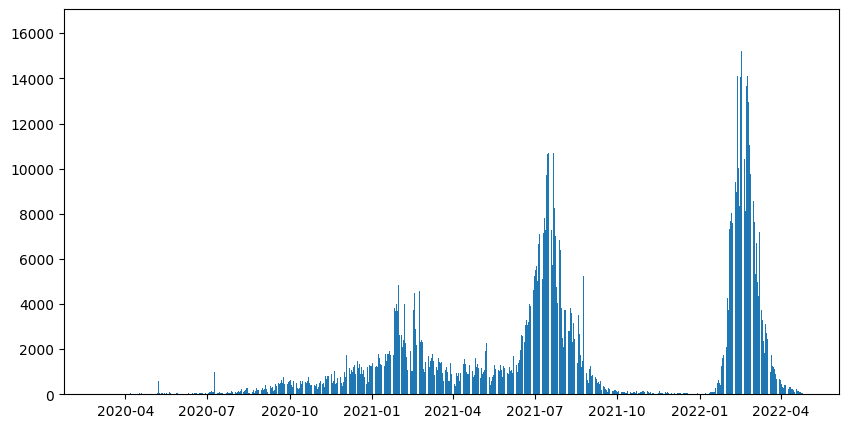

In [37]:
import matplotlib.pyplot as plt

#Membersihkan plot sebelumnya
plt.clf()

#Membuat figure & axis
fig, ax = plt.subplots(figsize=(10,5))

#Membuat grafik batang
ax.bar(data=cov_jabar_tidy, x='tanggal', height='kasus_baru')

#Menampilkan grafik
plt.show()

Visualisasi yang lebih informatif

/tmp/ipykernel_1871/3164533650.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticks(), rotation=90)


<Figure size 640x480 with 0 Axes>

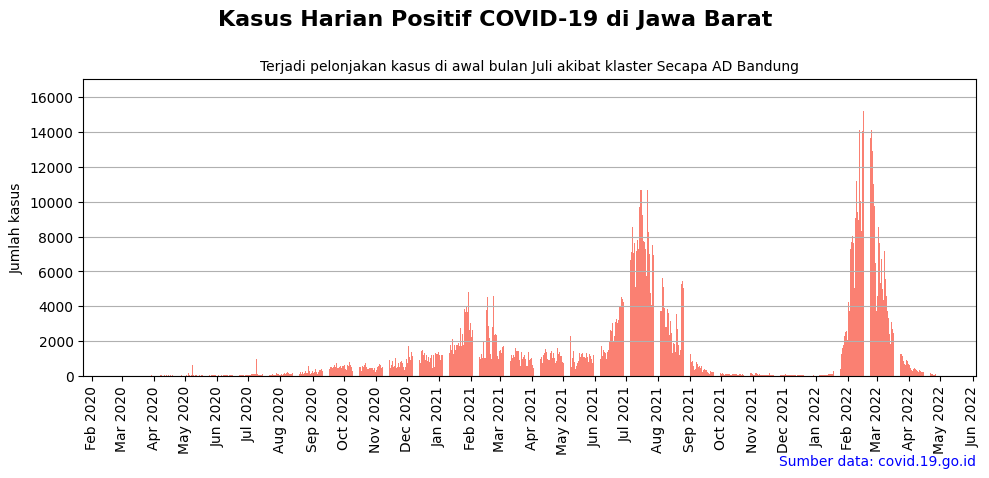

In [38]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates #import tambahan untuk format tanggal

plt.clf()

#Membuat grafik batang
fig, ax = plt.subplots(figsize=(10,5))
ax.bar(data=cov_jabar_tidy, x='tanggal', height='kasus_baru', color='salmon')

#Judul utama
fig.suptitle('Kasus Harian Positif COVID-19 di Jawa Barat',
             y=1.00, fontsize=16, fontweight='bold', ha='center')

#Sub judul
ax.set_title('Terjadi pelonjakan kasus di awal bulan Juli akibat klaster Secapa AD Bandung',
             fontsize=10)

#Label sumbu
ax.set_xlabel('')
ax.set_ylabel('Jumlah kasus')

#Sumber data (footer)
ax.text(1, -0.3, 'Sumber data: covid.19.go.id', color='blue',
        ha='right', transform=ax.transAxes)

#Merotasi label tanggal
ax.set_xticklabels(ax.get_xticks(), rotation=90)

#Format sumbu tanggal
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.grid(axis='y')
plt.tight_layout()
plt.show()

Visualisasi tersebut menunjukkan bahwa perkembangan COVID-19 di Jawa Barat berlangsung dalam pola bergelombang, bukan peningkatan yang stabil. Pada awal pandemi tahun 2020, jumlah kasus harian masih relatif rendah, namun mulai meningkat secara bertahap hingga mencapai lonjakan signifikan pada pertengahan 2021, yang berkaitan dengan munculnya klaster besar seperti Secapa AD Bandung. Puncak tertinggi kasus harian terjadi pada awal 2022, yang mengindikasikan adanya gelombang besar berikutnya dengan tingkat penularan yang sangat tinggi.

Jumlah kasus meninggal harian

/tmp/ipykernel_1871/803178015.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticks(), rotation=90)


<Figure size 640x480 with 0 Axes>

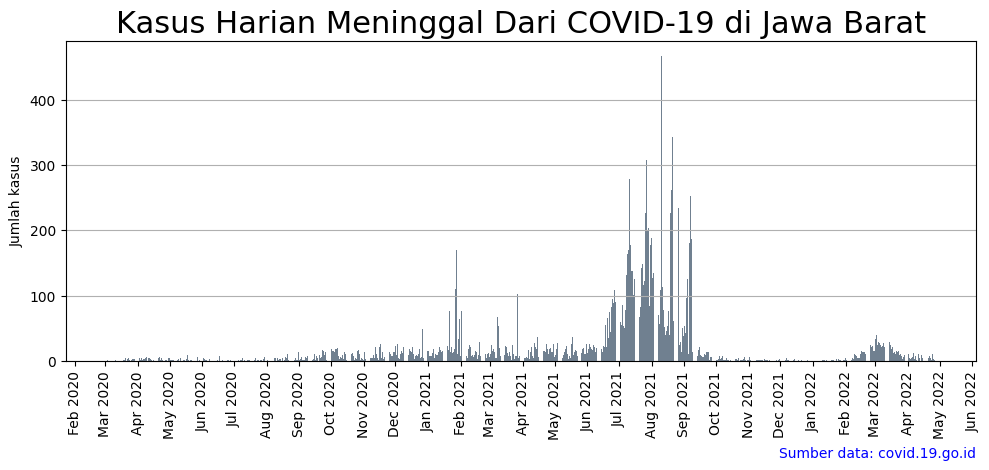

In [40]:
plt.clf()
fig, ax = plt.subplots(figsize=(10,5))
ax.bar(data=cov_jabar_tidy, x='tanggal', height='meninggal', color='slategrey')
ax.set_title('Kasus Harian Meninggal Dari COVID-19 di Jawa Barat',
             fontsize=22)
ax.set_xlabel('')
ax.set_ylabel('Jumlah kasus')
ax.text(1, -0.3, 'Sumber data: covid.19.go.id', color='blue',
        ha='right', transform=ax.transAxes)
ax.set_xticklabels(ax.get_xticks(), rotation=90)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.grid(axis='y')
plt.tight_layout()
plt.show()

Pada grafik kasus meninggal, terlihat bahwa lonjakan kasus positif diikuti oleh kenaikan jumlah kematian, tetapi dengan jeda waktu. Puncak kematian terjadi sekitar pertengahan hingga akhir 2021, bertepatan dengan periode tekanan tinggi pada sistem kesehatan. Namun, pada awal 2022 meskipun jumlah kasus meningkat jauh lebih tinggi, jumlah kematian tidak meningkat secara proporsional. Hal ini mengindikasikan adanya perbaikan dalam penanganan pandemi, seperti peningkatan kapasitas layanan kesehatan, vaksinasi, atau efektivitas pengobatan.

Jumlah pasien sembuh harian

/tmp/ipykernel_1871/3334916305.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticks(), rotation=90)


<Figure size 640x480 with 0 Axes>

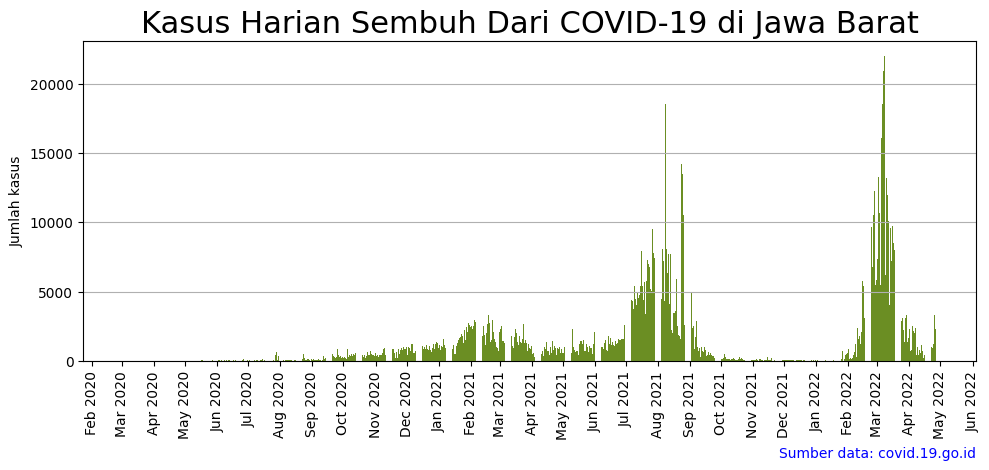

In [39]:
plt.clf()
fig, ax = plt.subplots(figsize=(10,5))
ax.bar(data=cov_jabar_tidy, x='tanggal', height='sembuh', color='olivedrab')
ax.set_title('Kasus Harian Sembuh Dari COVID-19 di Jawa Barat',
             fontsize=22)
ax.set_xlabel('')
ax.set_ylabel('Jumlah kasus')
ax.text(1, -0.3, 'Sumber data: covid.19.go.id', color='blue',
        ha='right', transform=ax.transAxes)
ax.set_xticklabels(ax.get_xticks(), rotation=90)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.grid(axis='y')
plt.tight_layout()
plt.show()

Grafik kesembuhan menunjukkan pola yang sejalan dengan kenaikan kasus positif, di mana jumlah pasien sembuh meningkat tajam terutama pada periode lonjakan besar. Pada awal 2022, jumlah kesembuhan bahkan mencapai titik tertinggi, mencerminkan bahwa meskipun tingkat penularan tinggi, tingkat pemulihan juga semakin baik. Secara keseluruhan, visualisasi ini menggambarkan bahwa meskipun pandemi sempat mencapai puncak yang sangat tinggi, terutama pada tahun 2021–2022, kemampuan penanganan dan pemulihan juga mengalami peningkatan, sehingga dampak fatal dapat ditekan dibandingkan fase sebelumnya.

Apakah pekan ini lebih baik ?

In [41]:
#Mengubah data harian menjadi mingguan
cov_jabar_pekanan = (cov_jabar_tidy.set_index('tanggal')['kasus_baru']
                                   .resample('W') #mengelompokkan per minggu
                                   .sum() #menjumlahkan kasus dalam 1 minggu
                                   .reset_index() #mengembalikan index menjadi kolom biasa
                                   .rename(columns={'kasus_baru': 'jumlah'}) #mengganti nama kolom menjadi "jumlah"
                    )
#Menambah kolom tahun
cov_jabar_pekanan['tahun'] = cov_jabar_pekanan['tanggal'].apply(lambda x: x.year)
#Menambah minggu ke-berapa
cov_jabar_pekanan['pekan_ke'] = cov_jabar_pekanan['tanggal'].apply(lambda x: x.weekofyear)
#Menyusun ulang kolom
cov_jabar_pekanan = cov_jabar_pekanan[['tahun', 'pekan_ke', 'jumlah']]

print('Info cov_jabar_pekanan:')
print(cov_jabar_pekanan.info())
print('\nLima data teratas cov_jabar_pekanan:\n', cov_jabar_pekanan.head())

Info cov_jabar_pekanan:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113 entries, 0 to 112
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   tahun     113 non-null    int64
 1   pekan_ke  113 non-null    int64
 2   jumlah    113 non-null    int64
dtypes: int64(3)
memory usage: 2.8 KB
None

Lima data teratas cov_jabar_pekanan:
    tahun  pekan_ke  jumlah
0   2020        10       4
1   2020        11       5
2   2020        12      44
3   2020        13      80
4   2020        14      89


In [16]:
#pip install numpy

Analisis perbandingan antar minggu

In [42]:
import numpy as np
import pandas as pd

#Mengambil data minggu sebelumnya
#.shift() --> menggeset data ke bawah 1 baris, nilai minggu ke-n akan dibandingkan dengan minggu ke-n-1
cov_jabar_pekanan['jumlah_pekanlalu'] = cov_jabar_pekanan['jumlah'].shift().replace(np.nan, 0).astype(int)

#Menemtukan apakah kondisinya membaik
cov_jabar_pekanan['lebih_baik'] = cov_jabar_pekanan['jumlah'] < cov_jabar_pekanan['jumlah_pekanlalu']

print('Sepuluh data teratas:\n', cov_jabar_pekanan.head(10))

Sepuluh data teratas:
    tahun  pekan_ke  jumlah  jumlah_pekanlalu  lebih_baik
0   2020        10       4                 0       False
1   2020        11       5                 4       False
2   2020        12      44                 5       False
3   2020        13      80                44       False
4   2020        14      89                80       False
5   2020        15     176                89       False
6   2020        16     203               176       False
7   2020        17     136               203        True
8   2020        18     100               136        True
9   2020        19     914               100       False


Grafik mingguan per tahun

<Figure size 640x480 with 0 Axes>

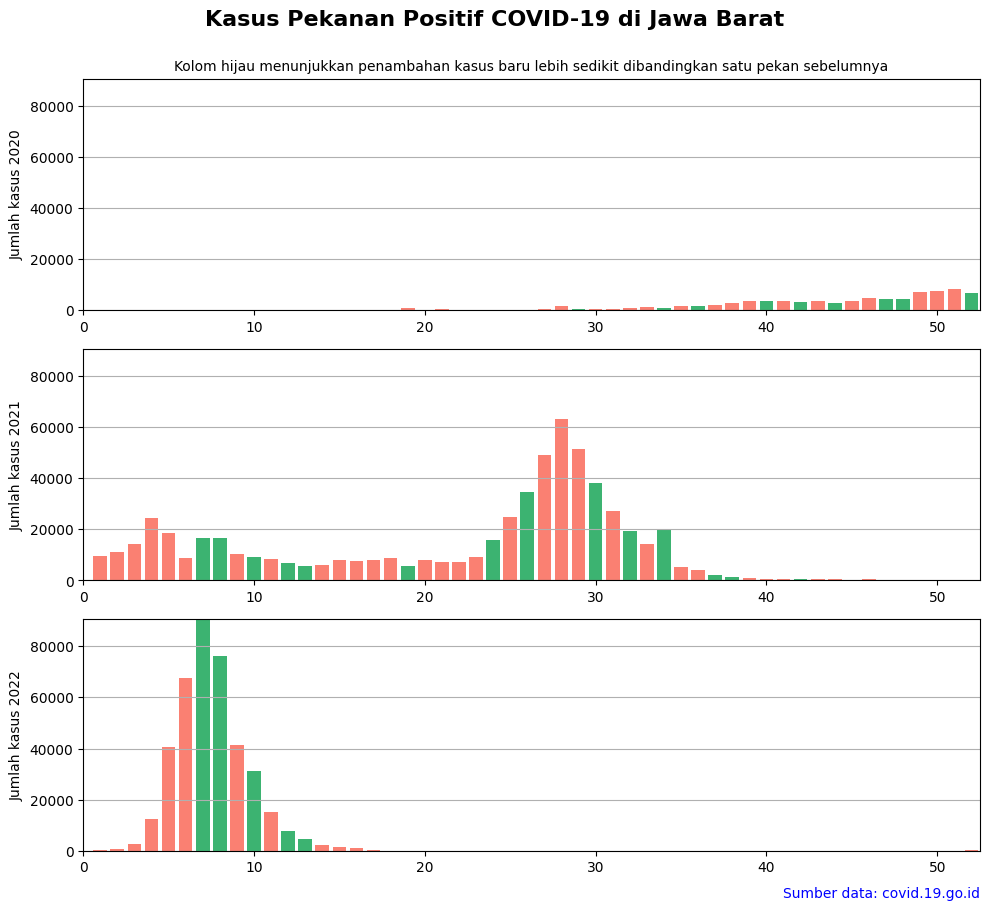

In [43]:
plt.clf()

#Menentukan jumlah subplot (per tahun)
jml_tahun_terjadi_covid19 = cov_jabar_pekanan['tahun'].nunique()
tahun_terjadi_covid19 = cov_jabar_pekanan['tahun'].unique()

#Membuat subplot dinamis (setiap subplot=1 tahun)
fig, axes = plt.subplots(nrows=jml_tahun_terjadi_covid19,
                         figsize=(10,3*jml_tahun_terjadi_covid19))

#Judul utama
fig.suptitle('Kasus Pekanan Positif COVID-19 di Jawa Barat',
             y=1.00, fontsize=16, fontweight='bold', ha='center')

#Loop untuk setiap tahun
for i, ax in enumerate(axes):
    ax.bar(data=cov_jabar_pekanan.loc[cov_jabar_pekanan['tahun']==tahun_terjadi_covid19[i]], #filter data per tahun
           x='pekan_ke', height='jumlah',
           color=['mediumseagreen' if x is True else 'salmon'
                  for x in cov_jabar_pekanan['lebih_baik']])
    if i == 0: #Anotasi khusus
        ax.set_title('Kolom hijau menunjukkan penambahan kasus baru lebih sedikit dibandingkan satu pekan sebelumnya',
                     fontsize=10)
    elif i == jml_tahun_terjadi_covid19-1:
        ax.text(1, -0.2, 'Sumber data: covid.19.go.id', color='blue',
            ha='right', transform=ax.transAxes)

    ax.set_xlim([0, 52.5])
    ax.set_ylim([0, max(cov_jabar_pekanan['jumlah'])])
    ax.set_xlabel('')
    ax.set_ylabel('Jumlah kasus %d'%(tahun_terjadi_covid19[i],))
    ax.grid(axis='y')

plt.tight_layout()
plt.show()

Pada grafik kasus pekanan, terlihat bahwa tahun 2020 didominasi oleh jumlah kasus yang relatif rendah dan stabil, mencerminkan fase awal pandemi. Memasuki tahun 2021, terjadi peningkatan signifikan dengan puncak pada sekitar pertengahan tahun, yang menunjukkan gelombang besar pertama. Warna batang yang didominasi merah pada periode tersebut menandakan bahwa jumlah kasus terus meningkat dibanding minggu sebelumnya, sehingga kondisi pandemi memburuk secara konsisten. Sementara itu, pada tahun 2022, lonjakan kasus terjadi lebih cepat namun dalam durasi yang lebih singkat. Dan lebih banyak batang berwarna hijau setelah puncak, yang menunjukkan bahwa penurunan kasus juga berlangsung lebih cepat dibandingkan tahun sebelumnya.

Menghitung data akumulatif

In [44]:
#Membuat DataFrame baru
cov_jabar_akumulasi = cov_jabar_tidy[['tanggal']].copy() #hanya mengambil kolom tanggal

#Menghitung kasus aktif (akumulatif)
#.cumsum() --> menjumlahkan secara kumulatif dari hari ke hari, menunjukkan total kasus yang masih aktif (belum sembuh/meninggal)
cov_jabar_akumulasi['akumulasi_aktif'] = (cov_jabar_tidy['kasus_baru'] - cov_jabar_tidy['sembuh'] - cov_jabar_tidy['meninggal']).cumsum()

#Mengitung total sembuh (akumulatif)
cov_jabar_akumulasi['akumulasi_sembuh'] = cov_jabar_tidy['sembuh'].cumsum()

#Menghitung total meninggal
cov_jabar_akumulasi['akumulasi_meninggal'] = cov_jabar_tidy['meninggal'].cumsum()
print(cov_jabar_akumulasi.tail())

       tanggal  akumulasi_aktif  akumulasi_sembuh  akumulasi_meninggal
780 2022-04-22            10753           1078344                15735
781 2022-04-23             9882           1079297                15737
782 2022-04-24             8709           1080519                15748
783 2022-04-25             5428           1083851                15751
784 2022-04-26             3253           1086129                15752


Visualisasi tren kasus aktif akumulatif

/tmp/ipykernel_1871/1331996753.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticks(), rotation=90)


<Figure size 640x480 with 0 Axes>

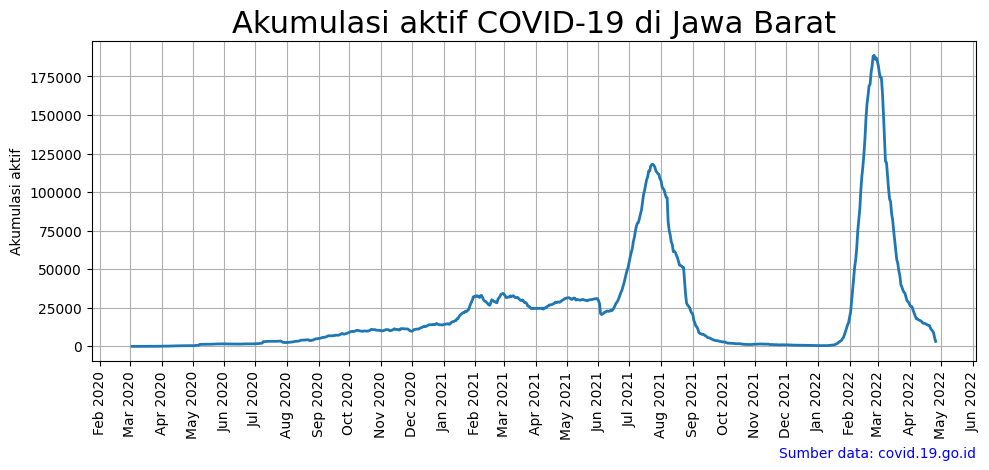

In [45]:
plt.clf()
fig, ax = plt.subplots(figsize=(10,5))
ax.plot('tanggal', 'akumulasi_aktif', data=cov_jabar_akumulasi, lw=2)

ax.set_title('Akumulasi aktif COVID-19 di Jawa Barat',
             fontsize=22)
ax.set_xlabel('')
ax.set_ylabel('Akumulasi aktif')
ax.text(1, -0.3, 'Sumber data: covid.19.go.id', color='blue',
        ha='right', transform=ax.transAxes)
ax.set_xticklabels(ax.get_xticks(), rotation=90)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.grid()
plt.tight_layout()
plt.show()

Grafik akumulasi kasus aktif menunjukkan dinamika beban pandemi terhadap sistem kesehatan. Terlihat bahwa jumlah kasus aktif meningkat perlahan sejak 2020, kemudian melonjak tajam pada pertengahan 2021 hingga mencapai puncak pertama. Setelah itu sempat menurun, namun kembali mengalami lonjakan yang jauh lebih tinggi pada awal 2022. Puncak kedua ini merupakan titik tertinggi selama pandemi, yang mengindikasikan tekanan terbesar terhadap fasilitas kesehatan. Namun penurunannya juga terlihat sangat cepat, menandakan bahwa meskipun penularan tinggi, durasi gelombang lebih singkat.

Grafik Gabungan (multi-line chart)

<Figure size 640x480 with 0 Axes>

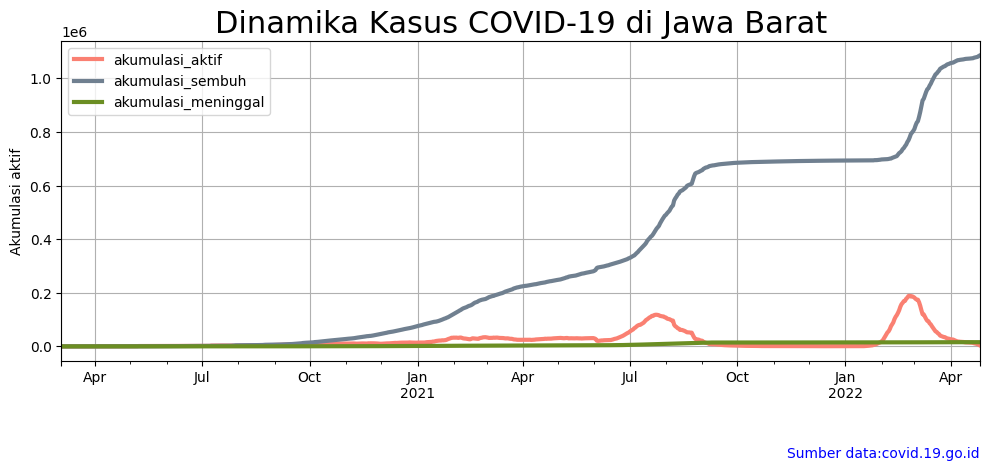

In [46]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
plt.clf()
fig, ax = plt.subplots(figsize=(10,5))

#Menjadikan tanggal sebagai index
cov_jabar_akumulasi_ts = cov_jabar_akumulasi.set_index('tanggal')

#Plot semua kolom sekaligus
cov_jabar_akumulasi_ts.plot(kind='line', ax=ax, lw=3,
						   color=['salmon','slategrey','olivedrab'])
ax.set_title('Dinamika Kasus COVID-19 di Jawa Barat', fontsize=22)
ax.set_xlabel('')
ax.set_ylabel('Akumulasi aktif')
ax.text(1, -0.3,'Sumber data:covid.19.go.id', color='blue', ha='right', transform=ax.transAxes)

plt.grid()
plt.tight_layout()
plt.show()

Sementara itu, grafik dinamika kasus kumulatif memperlihatkan hubungan antara kasus aktif, sembuh, dan meninggal secara bersamaan. Garis kesembuhan terus meningkat secara signifikan dan menjadi komponen terbesar, menunjukkan bahwa mayoritas kasus berakhir dengan pemulihan. Garis kematian meningkat relatif landai, menandakan bahwa fatalitas tetap ada tetapi tidak sebesar jumlah kesembuhan. Adapun garis kasus aktif menunjukkan pola naik-turun yang mencerminkan gelombang pandemi. Pada periode 2022, meskipun terjadi lonjakan kasus aktif yang tinggi, garis kesembuhan meningkat jauh lebih cepat, sehingga memperkuat indikasi bahwa tingkat pemulihan semakin baik.